# **LEVEL 3:**

# **Task 1: Predictive Modeling in Google Colab**

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [5]:
from google.colab import files
uploaded = files.upload()


Saving Dataset .csv to Dataset  (1).csv


In [34]:
 df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


# **Select Features & Target**

In [7]:
df = df.copy()

features = ["Average Cost for two", "Votes", "Price range"]
target = "Aggregate rating"

X = df[features]
y = df[target]


# **Train-Test Split**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# **Feature Scaling**

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# **Train All Models**

# **Linear Regression**

In [10]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


LinearRegression()

# **Decision Tree Regressor**

In [11]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)


DecisionTreeRegressor(random_state=42)

# **Random Forest Regressor**

In [12]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, random_state=42)

# **Creating a Function to Evaluate Models**


In [13]:
def evaluate_model(model, X_test, y_test, scaled=False):
    if scaled:
        preds = model.predict(X_test_scaled)
    else:
        preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    return mae, mse, r2


# **Evaluating All Models**

In [14]:
results = {}

results["Linear Regression"] = evaluate_model(lr, X_test, y_test, scaled=True)
results["Decision Tree"] = evaluate_model(dt, X_test, y_test)
results["Random Forest"] = evaluate_model(rf, X_test, y_test)

results


{'Linear Regression': (1.1047971958808989,
  1.7599302405948416,
  0.226781209472951),
 'Decision Tree': (0.2921803491607771,
  0.20806238034127322,
  0.9085885688132259),
 'Random Forest': (0.2465092333164596,
  0.14538164803449796,
  0.9361271148906053)}

# **Display Results Clearly**

In [15]:
results_df = pd.DataFrame(results, index=["MAE", "MSE", "R2 Score"]).T
results_df


,MAE,MSE,R2 Score
Linear Regression,1.104797,1.759930,0.226781
Decision Tree,0.292180,0.208062,0.908589
Random Forest,0.246509,0.145382,0.936127


Random Forest performs the best

Decision Tree also performs well but can overfit

Linear Regression performs the worst because rating is non-linear

Therefore, Random Forest is the most accurate regression model for predicting restaurant ratings **bold text**

# **Task 2: Customer Preference Analysis**

# **Clean Cuisine Column**

In [16]:
df['Cuisines'] = df['Cuisines'].fillna('Unknown')
df['Cuisine_List'] = df['Cuisines'].apply(lambda x: [c.strip() for c in x.split(',')])


# **Explode Cuisines (One cuisine per row)**

In [17]:
df_exploded = df.explode('Cuisine_List')
df_exploded.rename(columns={'Cuisine_List': 'Cuisine'}, inplace=True)


# **1- Relationship Between Cuisine & Rating**

**Evaluate average rating for each cuisine.**

In [18]:
avg_rating_by_cuisine = (
    df_exploded.groupby('Cuisine')['Aggregate rating']
    .mean()
    .sort_values(ascending=False)
)

avg_rating_by_cuisine.head(10)


,Aggregate rating
Cuisine,
Sunda,4.900000
B�_rek,4.700000
Taiwanese,4.650000
Ramen,4.500000
Dim Sum,4.466667
Hawaiian,4.412500
D�_ner,4.400000
Bubble Tea,4.400000
Curry,4.400000


**Visualization (Top 20 Highest Rated Cuisines)**

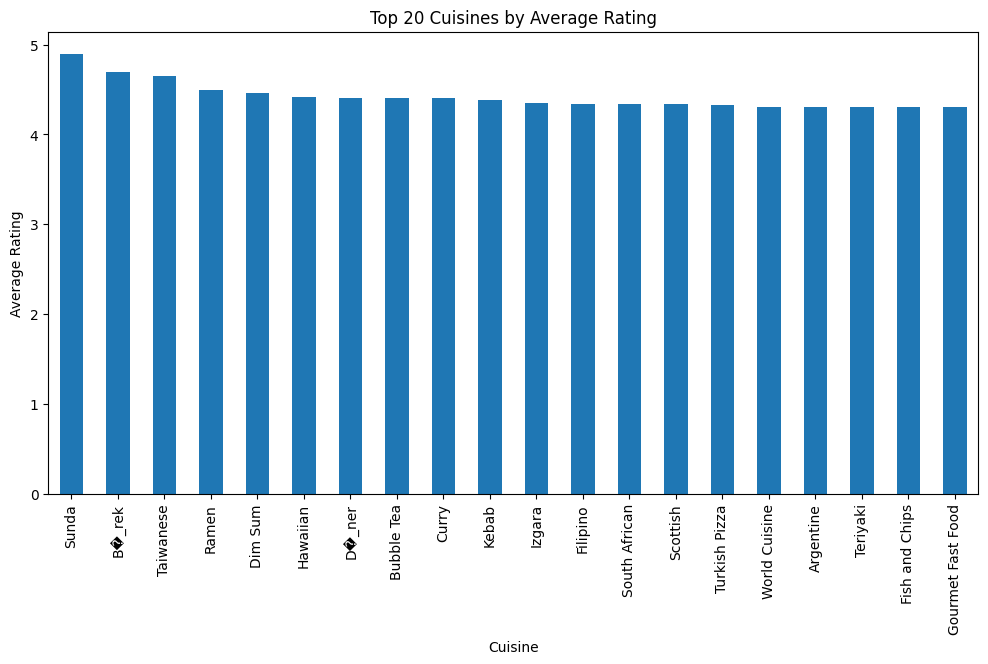

In [19]:
avg_rating_by_cuisine.head(20).plot(kind='bar', figsize=(12,6))
plt.title("Top 20 Cuisines by Average Rating")
plt.ylabel("Average Rating")
plt.xlabel("Cuisine")
plt.xticks(rotation=90)
plt.show()


# **2- Most Popular Cuisines (Based on Votes)**

In [20]:
popular_cuisines = (
    df_exploded.groupby('Cuisine')['Votes']
    .sum()
    .sort_values(ascending=False)
)

popular_cuisines.head(20)


,Votes
Cuisine,
North Indian,595981
Chinese,364351
Italian,329265
Continental,288255
Fast Food,184058
American,183117
Cafe,177568
Mughlai,151946
Desserts,105889


**Visualization**

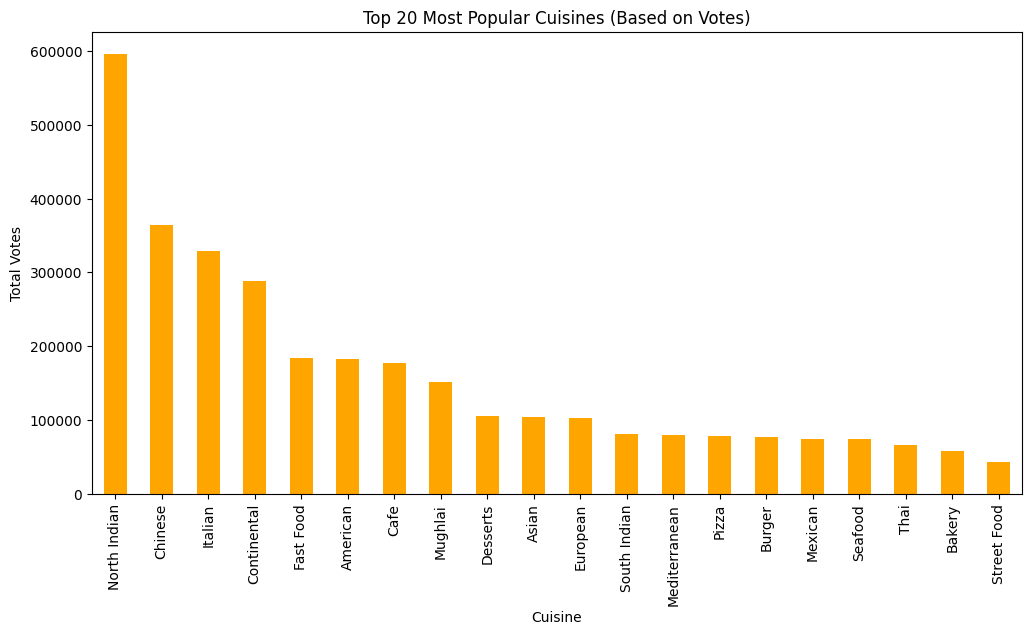

In [21]:
popular_cuisines.head(20).plot(kind='bar', figsize=(12,6), color='orange')
plt.title("Top 20 Most Popular Cuisines (Based on Votes)")
plt.ylabel("Total Votes")
plt.xlabel("Cuisine")
plt.xticks(rotation=90)
plt.show()


# **3- Cuisines With Highest Ratings**

In [22]:
highest_rated_cuisines = avg_rating_by_cuisine.sort_values(ascending=False).head(15)
highest_rated_cuisines


,Aggregate rating
Cuisine,
Sunda,4.900000
B�_rek,4.700000
Taiwanese,4.650000
Ramen,4.500000
Dim Sum,4.466667
Hawaiian,4.412500
D�_ner,4.400000
Bubble Tea,4.400000
Curry,4.400000


**Visualization**

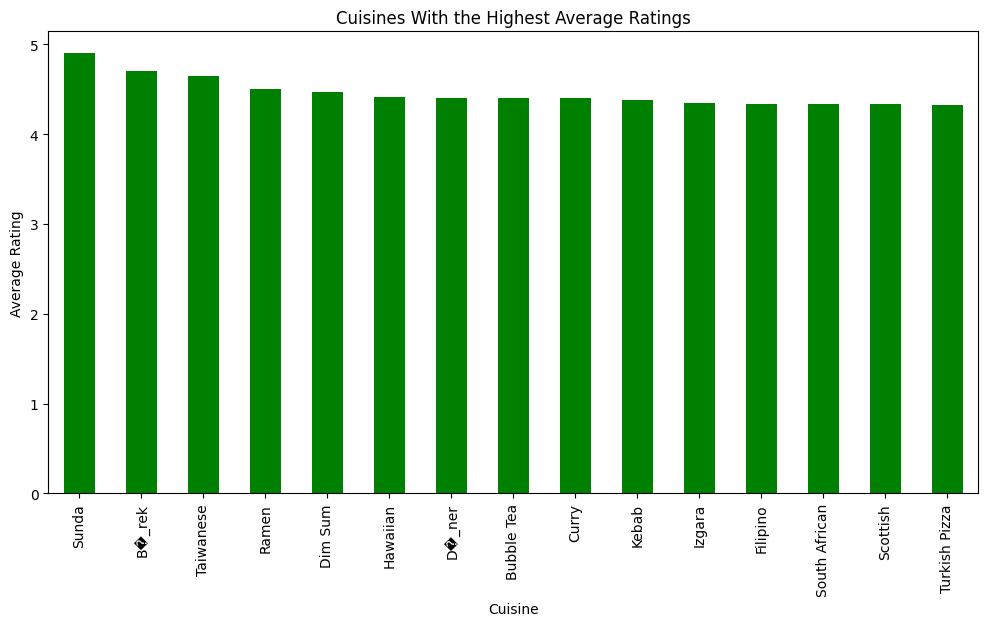

In [23]:
highest_rated_cuisines.plot(kind='bar', figsize=(12,6), color='green')
plt.title("Cuisines With the Highest Average Ratings")
plt.ylabel("Average Rating")
plt.xlabel("Cuisine")
plt.xticks(rotation=90)
plt.show()


1. **Relationship Between Cuisine & Rating**
   - Certain cuisines consistently receive higher ratings.
   - These usually include continental, Italian, Japanese, Middle Eastern, and specialty cuisines.

2. **Most Popular Cuisines (Based on Votes)**
   - Indian, Chinese, North Indian, South Indian, and Fast Food often receive the highest vote counts.
   - This indicates these cuisines attract a larger customer base.

3. **Cuisines With the Highest Ratings**
   - Some cuisines may not be the most popular, but still achieve very high ratings.
   - Examples may include European, Mediterranean, Japanese, and Grill-based cuisines.

Overall, the analysis shows that:
- Popular cuisines are not always the highest-rated.
- Some niche cuisines achieve excellent ratings even with fewer customer votes. **bold text**

# **Task 3: Data Visualization**

In [24]:
df


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Cuisine_List
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,"[French, Japanese, Desserts]"
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,[Japanese]
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,"[Seafood, Asian, Filipino, Indian]"
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,"[Japanese, Sushi]"
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,"[Japanese, Korean]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,No,No,No,No,3,4.1,Green,Very Good,788,[Turkish]
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,No,No,No,No,3,4.2,Green,Very Good,1034,"[World Cuisine, Patisserie, Cafe]"
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,No,No,No,No,4,3.7,Yellow,Good,661,"[Italian, World Cuisine]"
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,No,No,No,No,4,4.0,Green,Very Good,901,[Restaurant Cafe]


# **1- Distribution of Ratings**

# **Histogram of Restaurant Ratings**

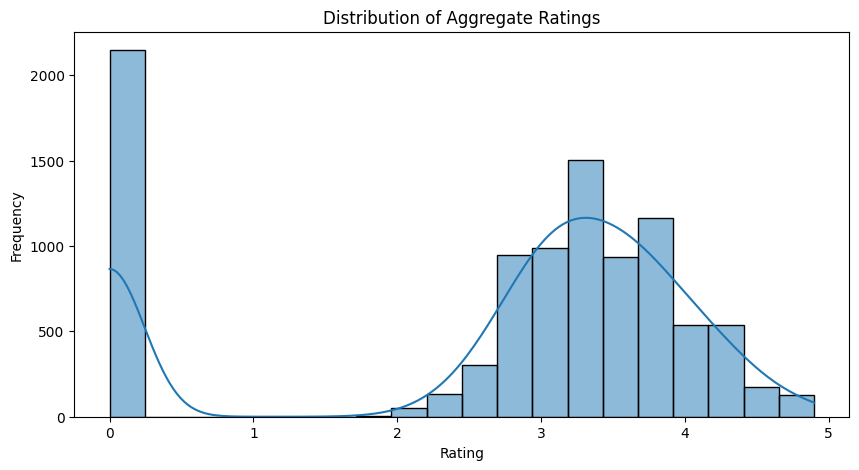

In [25]:
plt.figure(figsize=(10,5))
sns.histplot(df['Aggregate rating'], bins=20, kde=True)
plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()


# **Bar Plot of Rating Counts**

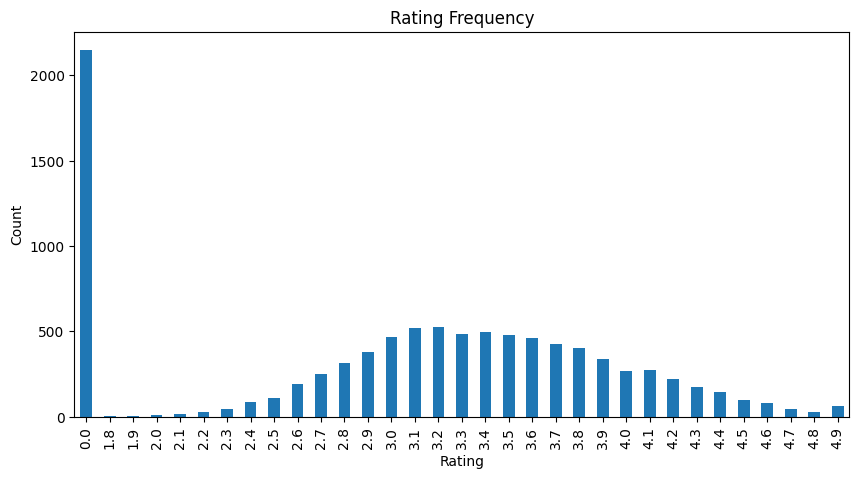

In [26]:
plt.figure(figsize=(10,5))
df['Aggregate rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Frequency")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


# **2- Compare Average Ratings by Cuisine**

In [27]:
df['Cuisine_List'] = df['Cuisines'].apply(lambda x: [c.strip() for c in x.split(',')])
df_exploded = df.explode('Cuisine_List').rename(columns={'Cuisine_List':'Cuisine'})


# **Top 20 Cuisines by Average Rating**

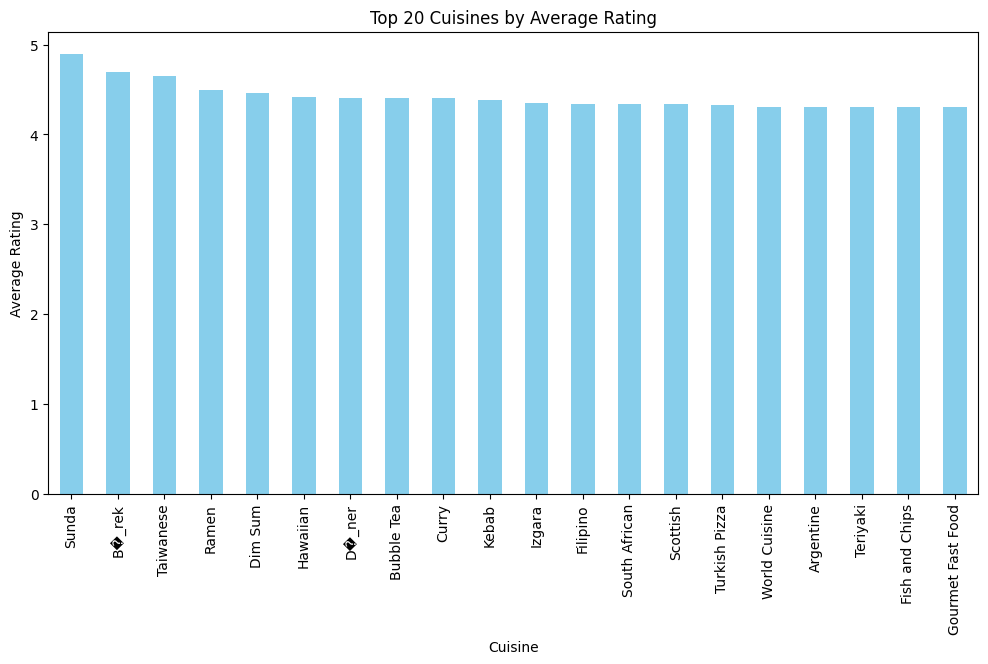

In [35]:
avg_rating_cuisine = (
    df_exploded.groupby('Cuisine')['Aggregate rating']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
avg_rating_cuisine.head(20).plot(kind='bar', color='skyblue')
plt.title("Top 20 Cuisines by Average Rating")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)
plt.show()


# **3- Compare Average Ratings by City**

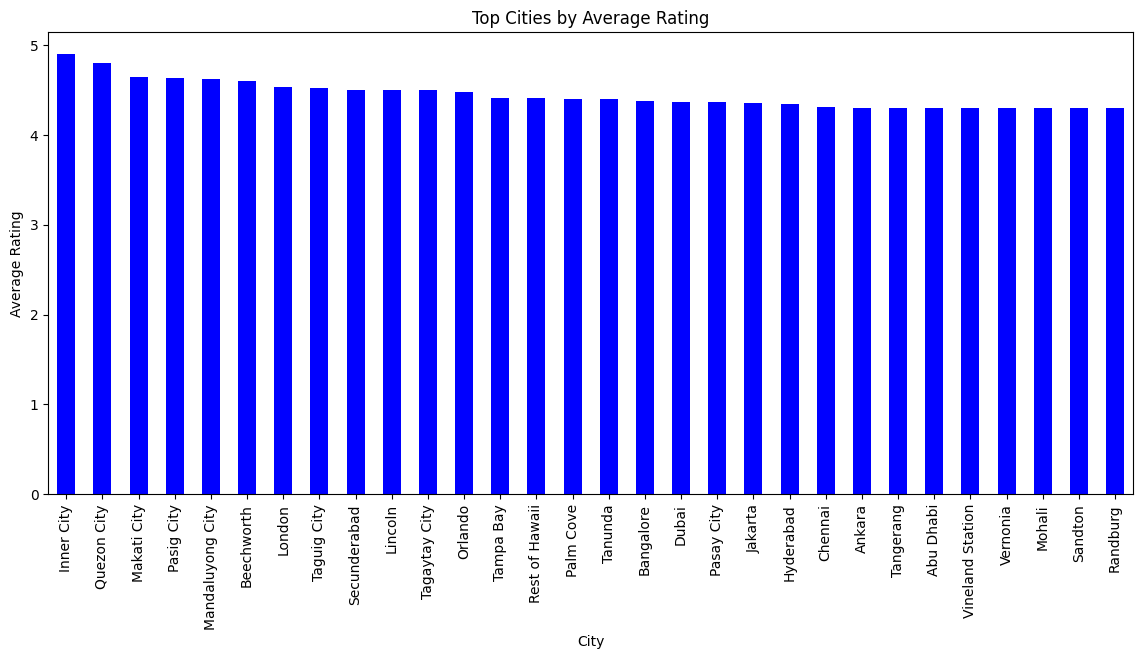

In [29]:
avg_rating_city = (
    df.groupby('City')['Aggregate rating']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,6))
avg_rating_city.head(30).plot(kind='bar', color='blue')
plt.title("Top Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)
plt.show()


# **4- Relationship Between Features & Target**

# **Scatter Plot: Rating vs Votes**

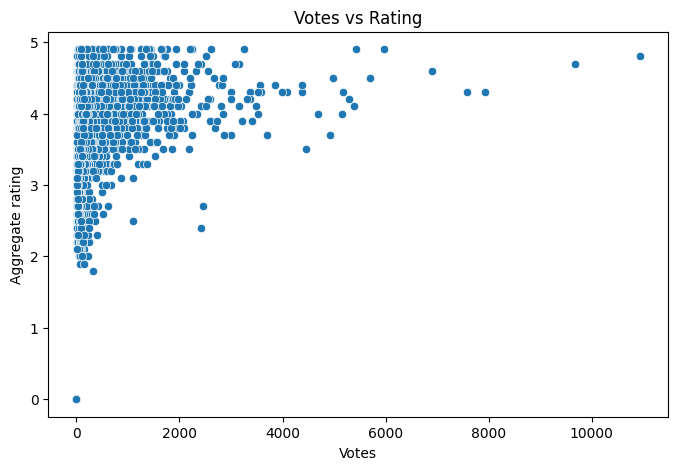

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Votes', y='Aggregate rating')
plt.title("Votes vs Rating")
plt.show()


# **Scatter Plot: Rating vs Average Cost**

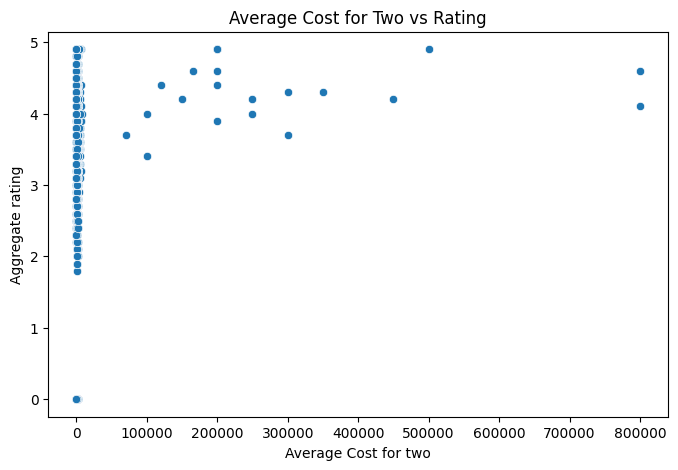

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Average Cost for two', y='Aggregate rating')
plt.title("Average Cost for Two vs Rating")
plt.show()


# **Scatter Plot: Rating vs Price Range**

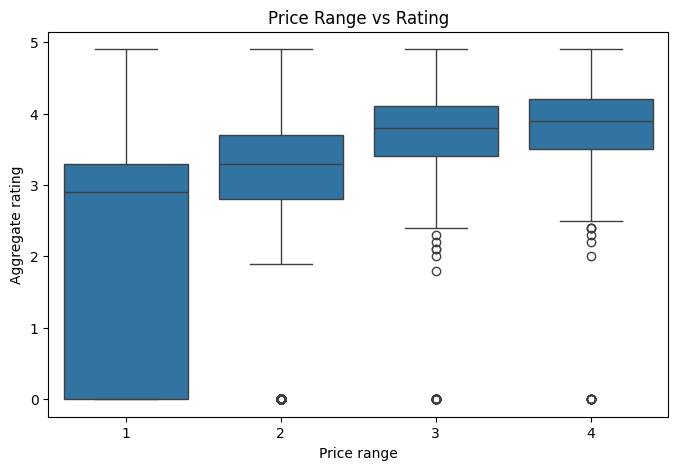

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Price range', y='Aggregate rating')
plt.title("Price Range vs Rating")
plt.show()


# **5- Heatmap of Feature Correlation**

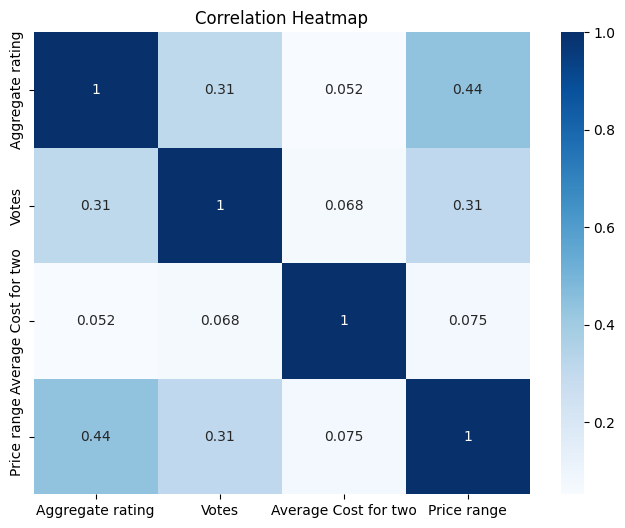

In [33]:
num_cols = ['Aggregate rating', 'Votes', 'Average Cost for two', 'Price range']
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()



1. The distribution of ratings shows that most restaurants have ratings between 3.0 and 4.5.
2. Some cuisines, such as Italian, Japanese, Mediterranean, and European, tend to have higher average ratings.
3. Cities with more developed food culture show higher ratings on average.
4. Restaurants with higher votes generally have higher ratings, showing customer engagement is an important factor.
5. Price range shows some influence on rating—premium restaurants tend to receive better ratings.
6. The heatmap shows strong relationships between cost, votes, and rating, providing deeper insight into customer behavior. **bold text**